In [97]:
import json
import os

import numpy as np
import pandas as pd

#dir = '../large_files/new_beam_matching_experiment_1nrec'
dir = '../data/results/experiments/new_beam_matching_experiment_15'

data_df = pd.read_csv(os.path.join(dir, 'data.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

data_df['n_best_pcis'] = data_df['n_best_pcis'].apply(lambda x: 'all' if np.isnan(x) else f'{int(x)}')
data_df['n_best_beams'] = data_df['n_best_beams'].apply(lambda x: 'all' if np.isnan(x) else f'{int(x)}')
data['runtime'] = data['runtime'] * 1000 / 2500


def get_strat(row):
    if row['n_best_pcis'] == 'all' and row['n_best_beams'] == 'all':
        return 'All PCIs and all beams'
    elif row['n_best_pcis'] == '1' and row['n_best_beams'] == 'all':
        return 'Only best PCI and all beams'
    elif row['n_best_pcis'] == 'all' and row['n_best_beams'] == '1':
        return 'All PCIs and only best beam'
    elif row['n_best_pcis'] == '1' and row['n_best_beams'] == '1':
        return 'Only best PCI and only best beam'
    return 'unknown strategy'


data_df['config'] = data_df.apply(get_strat, axis=1)

data_df


,errors,complexity,run,runtime,n_best_pcis,n_best_beams,operator,config
0,141.358768,117960.0,0.0,2.444041,all,all,1,All PCIs and all beams
1,0.857544,117960.0,0.0,2.444041,all,all,1,All PCIs and all beams
2,0.321023,117960.0,0.0,2.444041,all,all,1,All PCIs and all beams
3,15.670595,117960.0,0.0,2.444041,all,all,1,All PCIs and all beams
4,14.144853,117960.0,0.0,2.444041,all,all,1,All PCIs and all beams
...,...,...,...,...,...,...,...,...
405307,1.625666,242556.0,9.0,1.886465,1,1,88,Only best PCI and only best beam
405308,251.538532,242556.0,9.0,1.886465,1,1,88,Only best PCI and only best beam
405309,148.411853,242556.0,9.0,1.886465,1,1,88,Only best PCI and only best beam
405310,196.632314,242556.0,9.0,1.886465,1,1,88,Only best PCI and only best beam


In [104]:
res = []
for group, data in data_df.groupby(['n_best_pcis', 'n_best_beams', 'operator', 'config']):
    errors = data.groupby('run')['errors'].mean().values
    complexity = data.groupby('run')['complexity'].mean().values
    runtime = data.groupby('run')['runtime'].mean().values

    for i in range(errors.shape[0]):
        res.append((group[0], group[1], group[2], errors[i], complexity[i], group[3], runtime[i]))

order = [str(x) for x in range(1, 20)] + ['all']

df = pd.DataFrame(res,
                  columns=['n_best_pcis', 'n_best_beams', 'operator', 'errors', 'complexity', 'config', 'runtime'])
df['n_best_pcis'] = pd.Categorical(df['n_best_pcis'], categories=order, ordered=True)
df.sort_values(by=['n_best_pcis', 'n_best_beams'], inplace=True)

df[df['n_best_pcis'] == 'all']['errors'].mean()

df.groupby(['operator', 'config'])['errors'].mean()

operator  config                          
1         All PCIs and all beams               22.260757
          All PCIs and only best beam          22.260699
          Only best PCI and all beams          90.557925
          Only best PCI and only best beam     90.557925
10        All PCIs and all beams                4.109701
          All PCIs and only best beam          10.263492
          Only best PCI and all beams          26.627552
          Only best PCI and only best beam     44.077278
50        All PCIs and all beams                6.411648
          All PCIs and only best beam          15.394540
          Only best PCI and all beams          27.648513
          Only best PCI and only best beam     50.775854
88        All PCIs and all beams                4.982775
          All PCIs and only best beam          17.455462
          Only best PCI and all beams          49.427736
          Only best PCI and only best beam    106.207100
Name: errors, dtype: float64

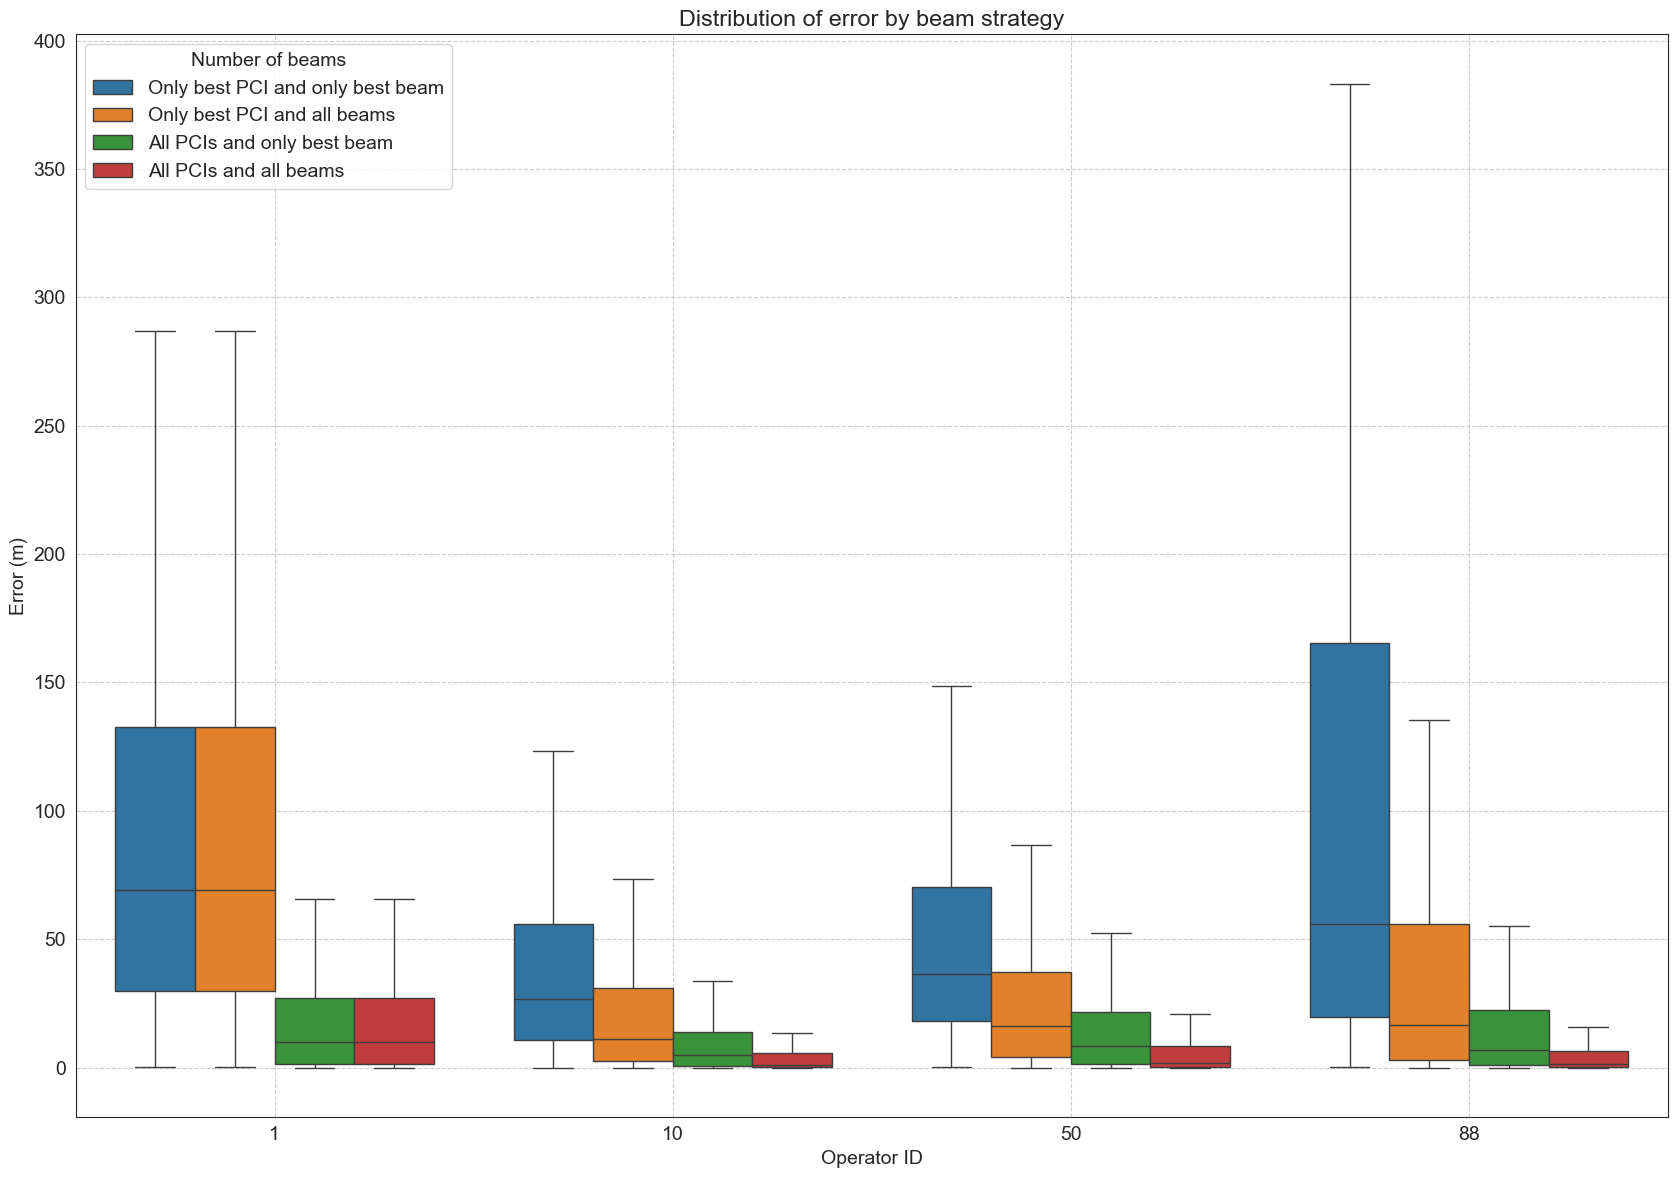

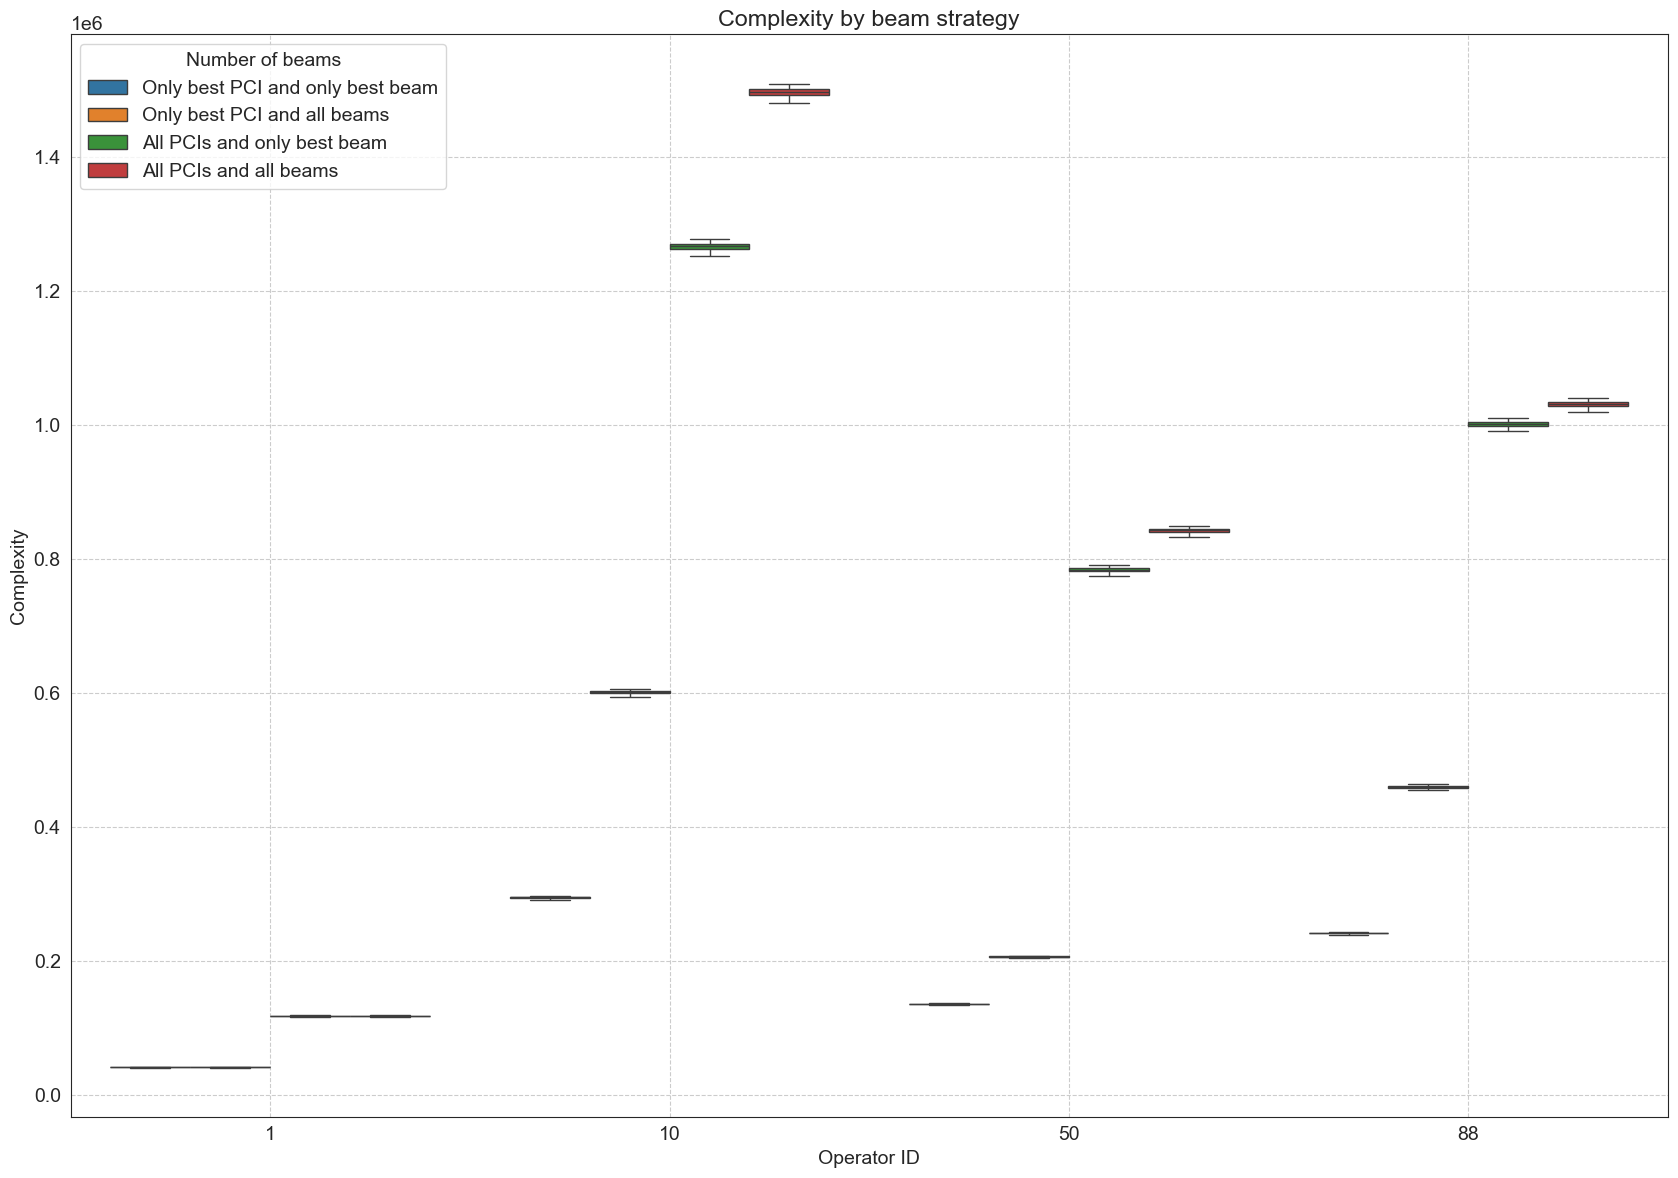

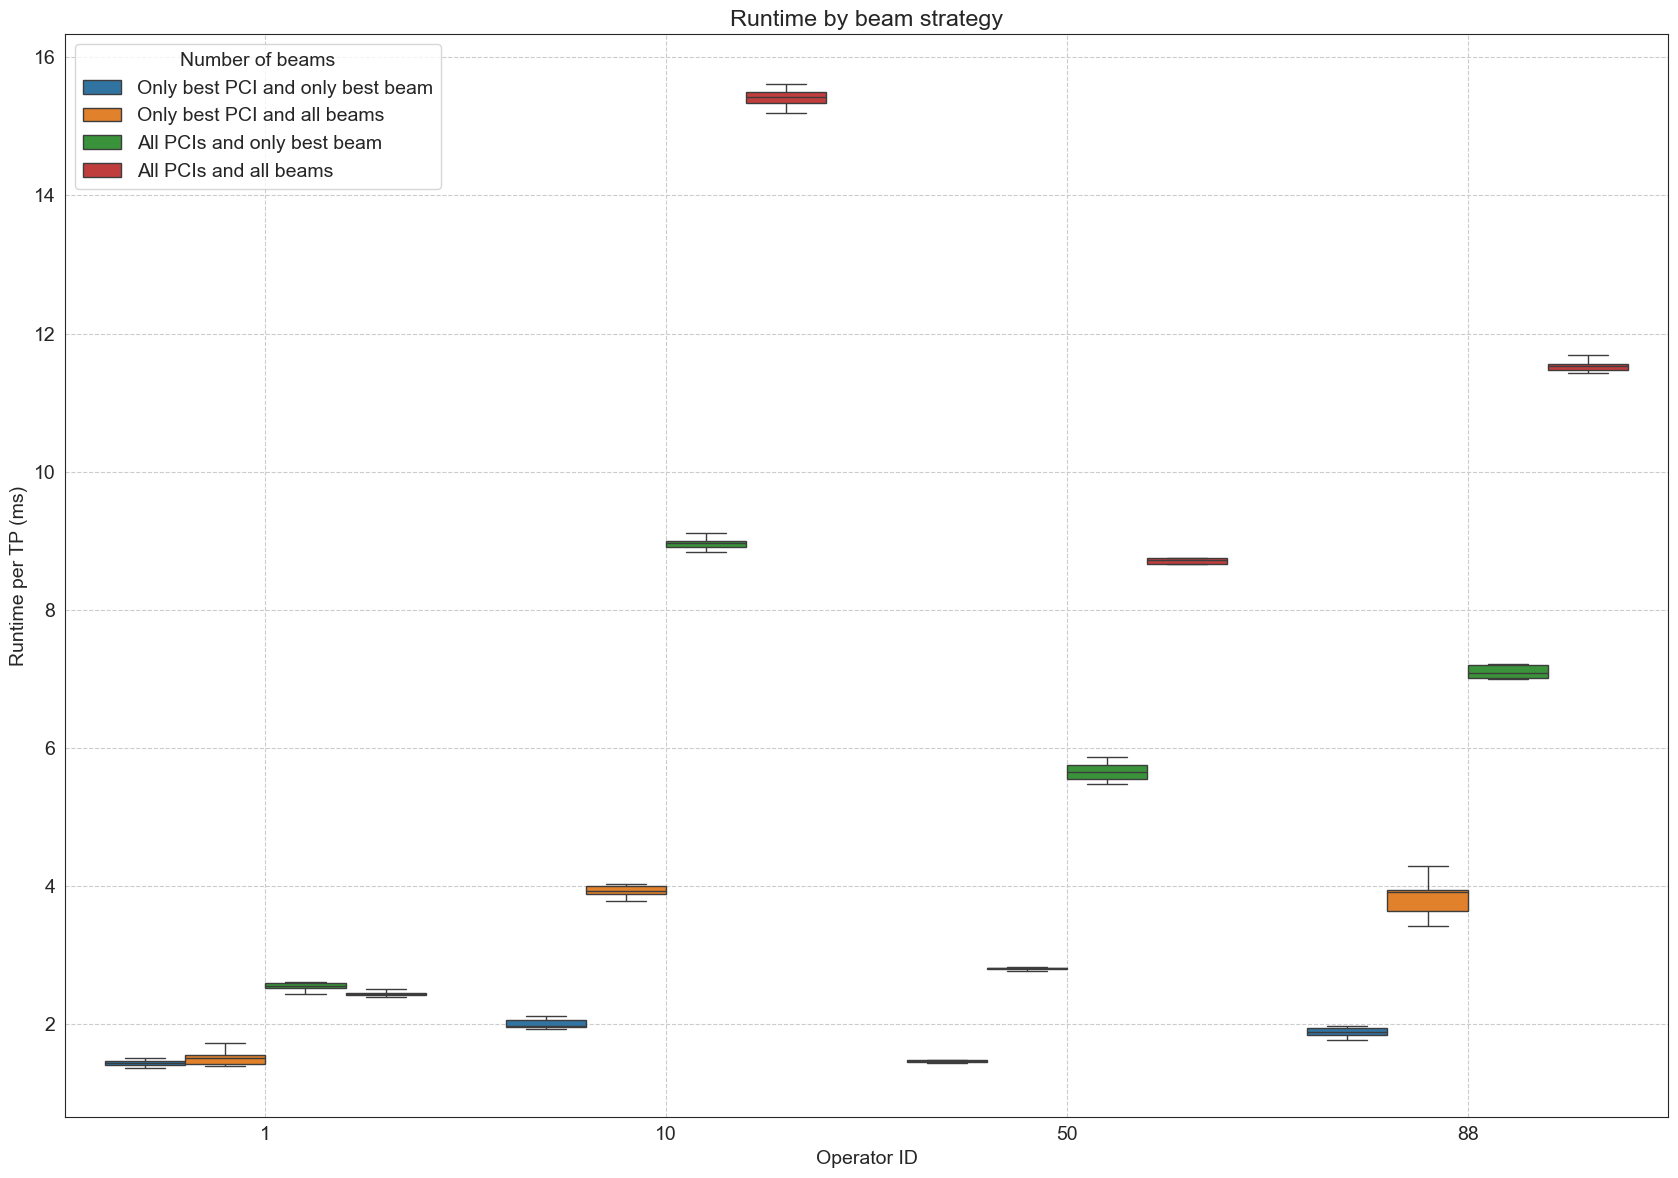

In [106]:


def plot_operator(
        df: pd.DataFrame,
        y: str,
        x_label: str,
        y_label: str,
        title: str,
):
    plt.rcParams.update({"font.size": 14})

    hue_order = [
        'Only best PCI and only best beam',
        'Only best PCI and all beams',
        'All PCIs and only best beam',
        'All PCIs and all beams',
    ]

    plt.figure(figsize=(17, 12))
    sns.set_style("white")
    sns.boxplot(
        data=df,
        x='operator',
        y=y,
        hue='config',
        hue_order=hue_order,
        showfliers=False,
    )

    #plt.axhline(y=baseline, color='r', linestyle='--')

    # Add labels and title
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)

    plt.legend(title='Number of beams', loc='upper left')
    plt.grid(linestyle='--')
    plt.tight_layout()
    plt.show()


plot_operator(data_df, 'errors', 'Operator ID', 'Error (m)', 'Distribution of error by beam strategy')
plot_operator(data_df, 'complexity', 'Operator ID', 'Complexity', 'Complexity by beam strategy')
plot_operator(data_df, 'runtime', 'Operator ID', 'Runtime per TP (ms)', 'Runtime by beam strategy')


/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_84010/3058471844.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lows['n_best_pcis'] = pd.Categorical(df_lows['n_best_pcis'], categories=lows, ordered=True)
/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_84010/3058471844.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_highs['n_best_pcis'] = pd.Categorical(df_highs['n_best_pcis'], categories=highs, ordered=True)


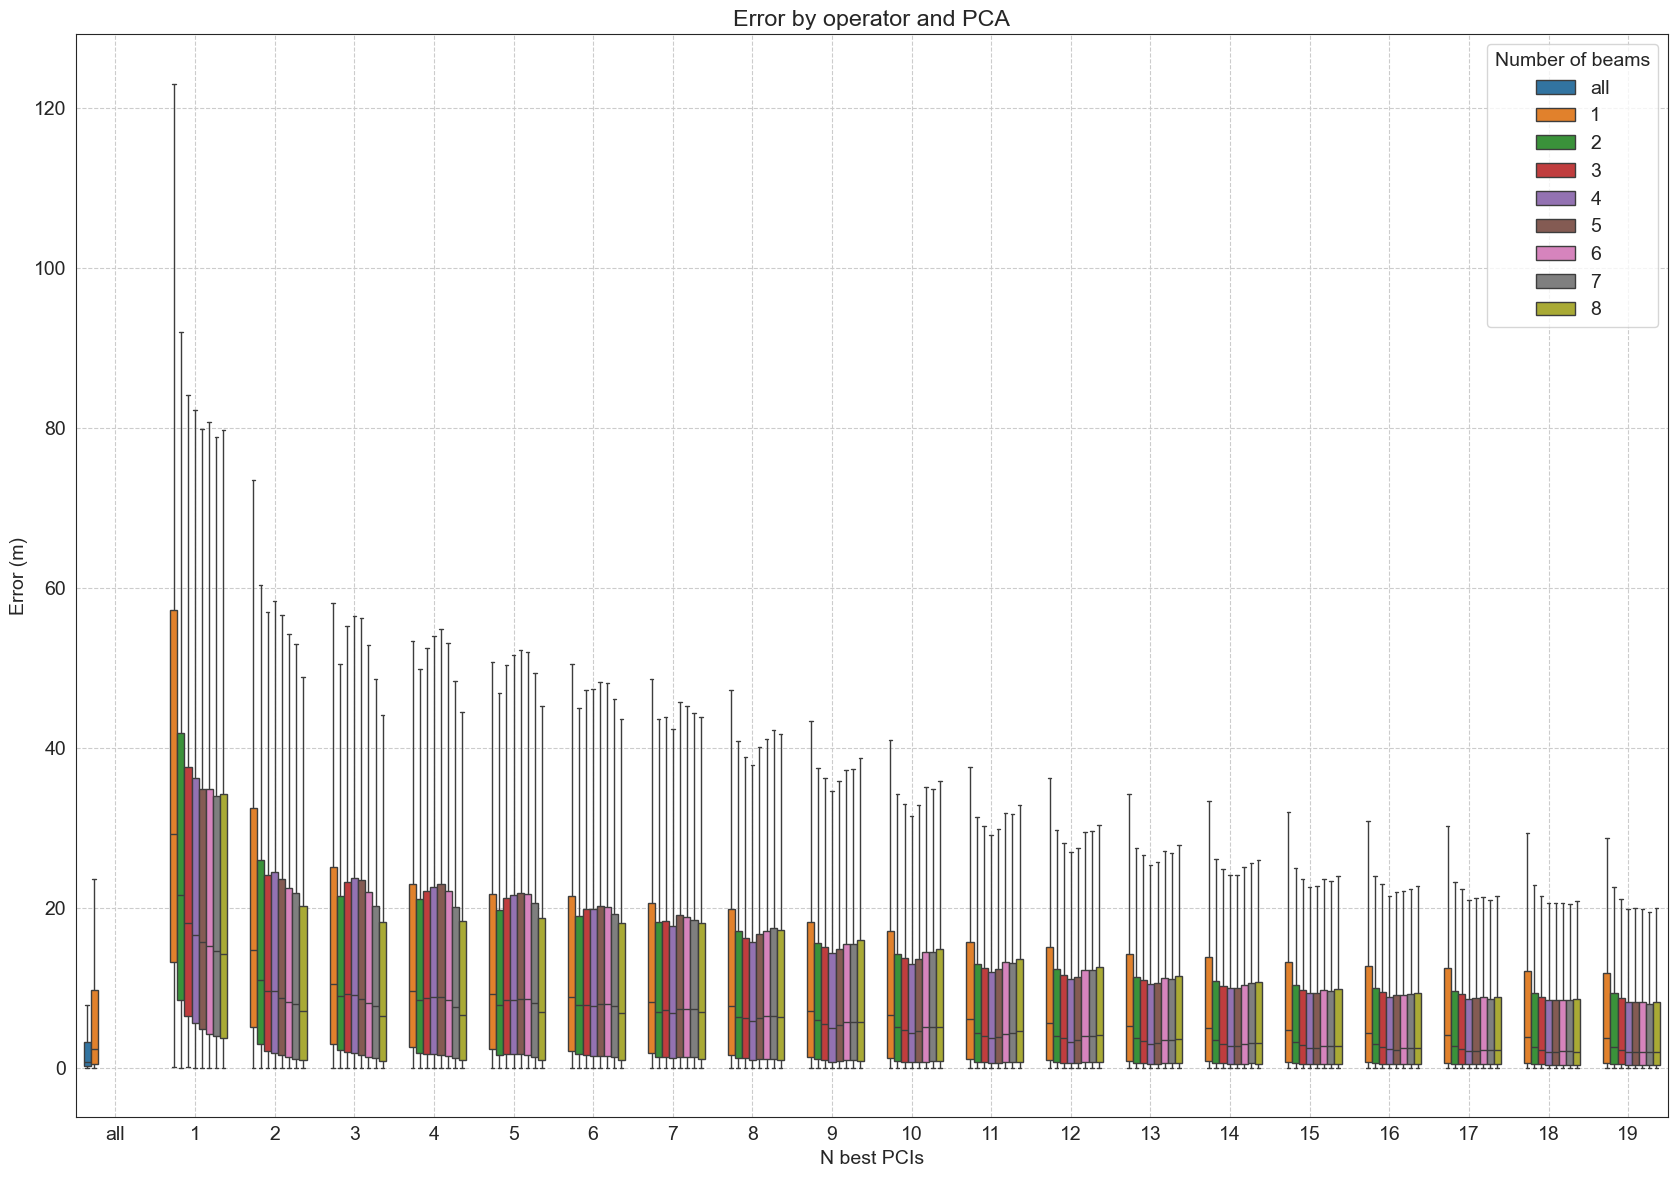

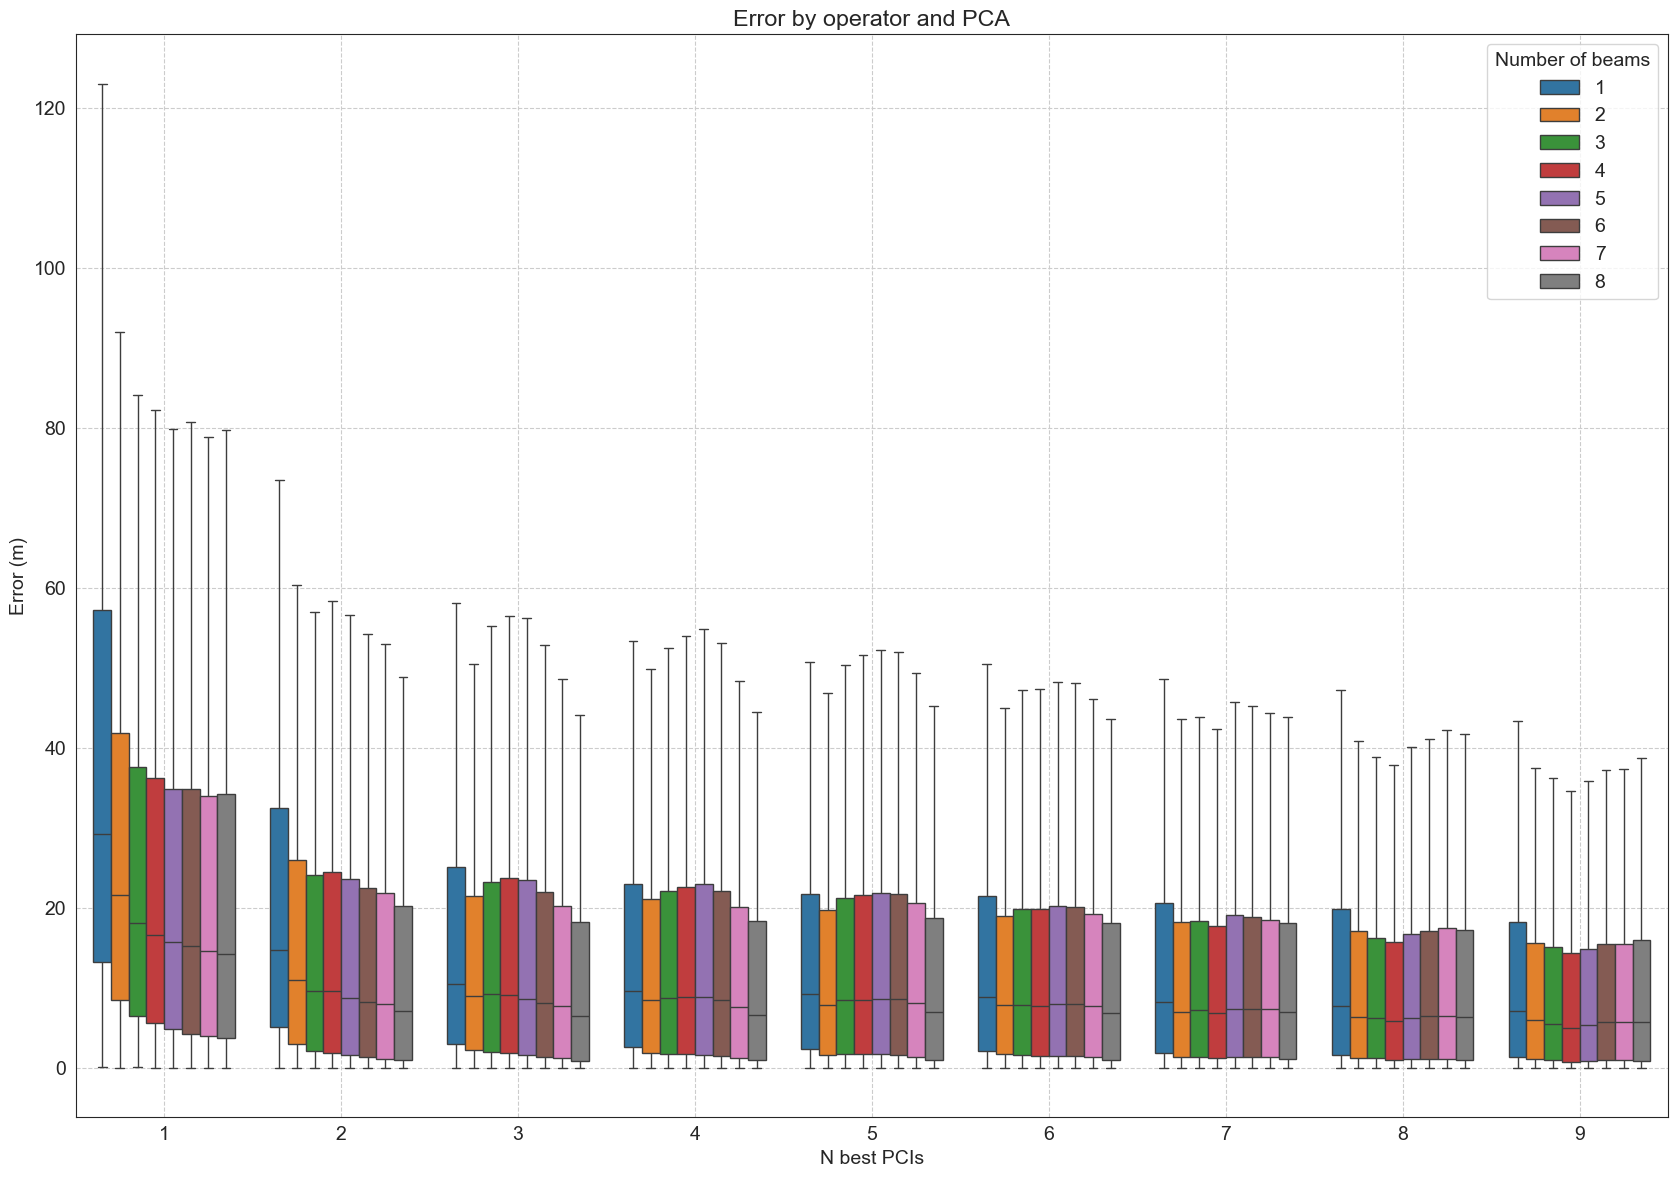

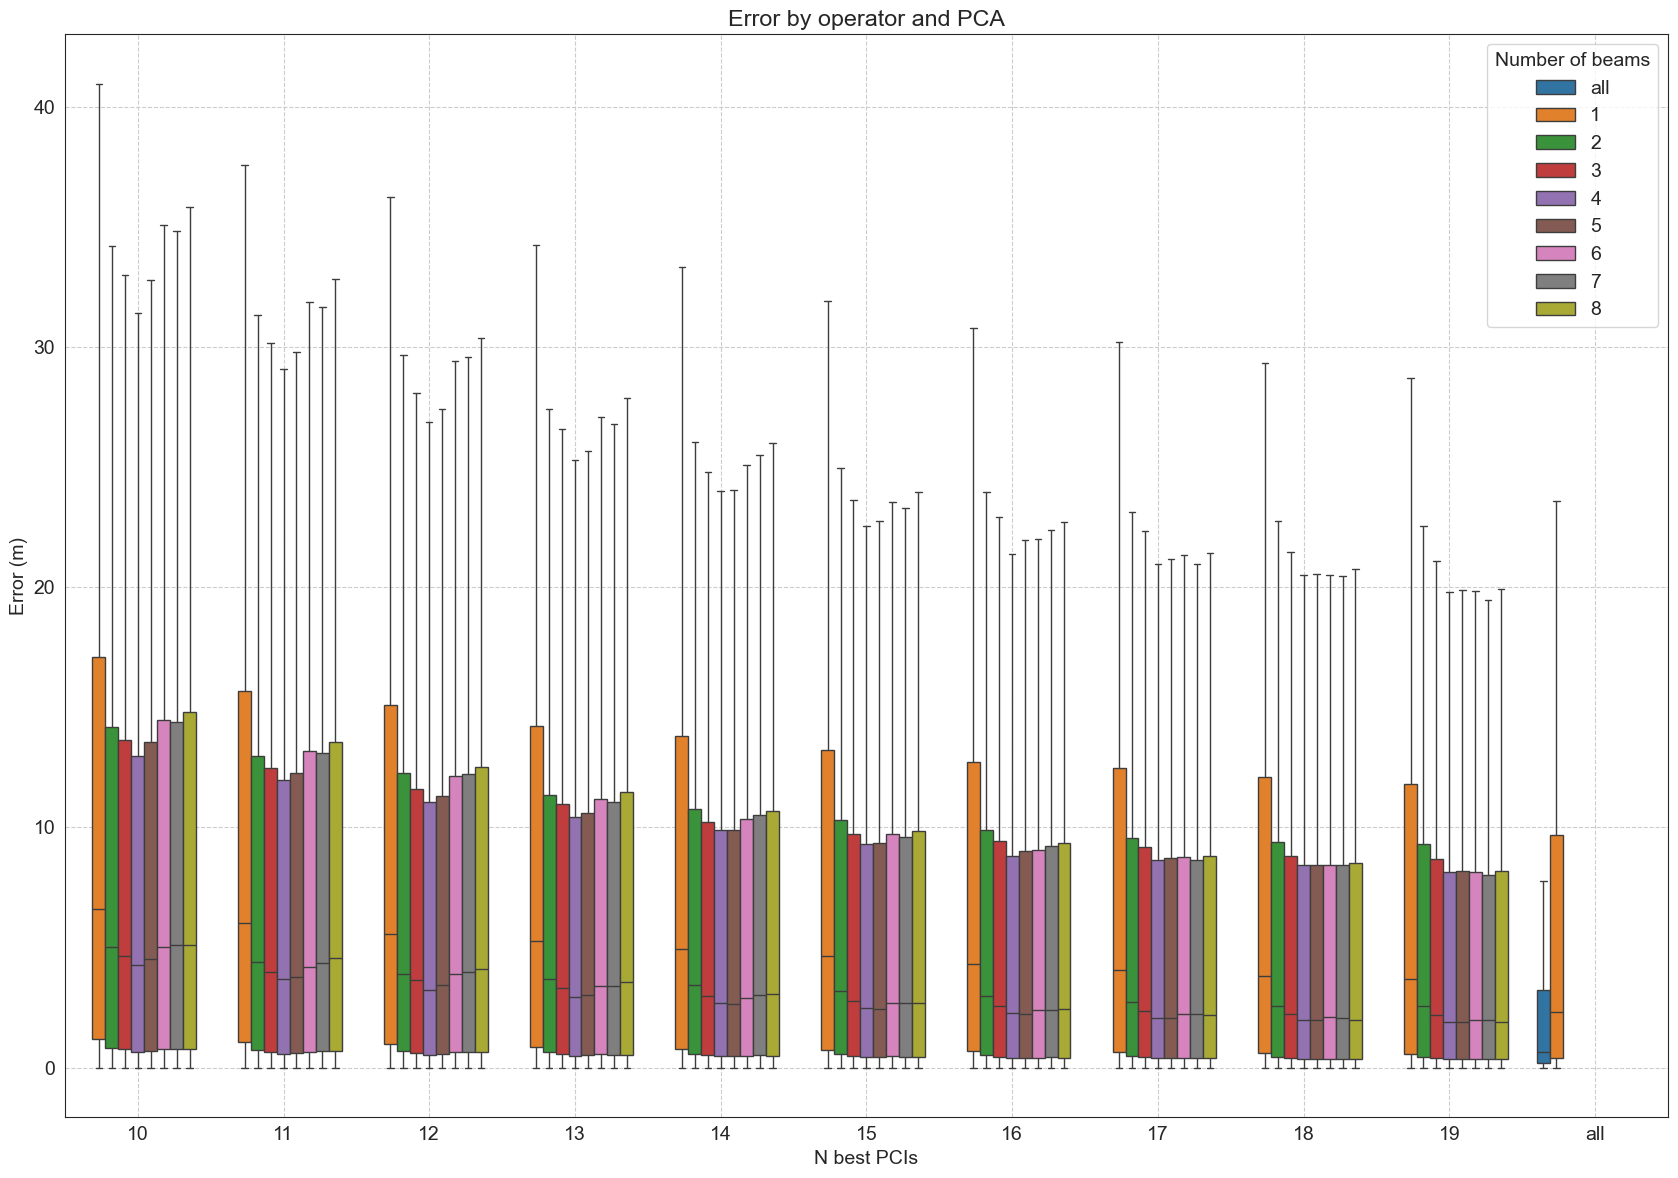

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot(df: pd.DataFrame):
    plt.rcParams.update({"font.size": 14})

    # baseline = df[df['n_best_pcis'] == 'all']['errors'].mean()
    #
    # data = df[df['n_best_pcis'] != 'all']

    plt.figure(figsize=(17, 12))
    sns.set_style("white")
    sns.boxplot(
        data=df,
        x='n_best_pcis',
        y='errors',
        hue='n_best_beams',
        showfliers=False,
    )

    #plt.axhline(y=baseline, color='r', linestyle='--')

    # Add labels and title
    plt.xlabel('N best PCIs')
    plt.ylabel('Error (m)')
    plt.title('Error by operator and PCA')

    plt.legend(title='Number of beams', loc='upper right')
    plt.grid(linestyle='--')
    plt.tight_layout()
    plt.show()


#plot(df[df['n_best_pcis'] == 9])

highs = [str(i) for i in range(10, 20)] + ['all']
lows = [str(i) for i in range(1, 10)]


#plot(data_df[data_df['n_best_pcis'].isin(highs)])
#plot(data_df[data_df['n_best_pcis'].isin(lows)])

def do_plot(df):
    df_lows = df[df['n_best_pcis'].isin(lows)]
    df_lows['n_best_pcis'] = pd.Categorical(df_lows['n_best_pcis'], categories=lows, ordered=True)

    df_highs = df[df['n_best_pcis'].isin(highs)]
    df_highs['n_best_pcis'] = pd.Categorical(df_highs['n_best_pcis'], categories=highs, ordered=True)

    # plot the points
    plot(df)
    plot(df_lows)
    plot(df_highs)


do_plot(data_df)

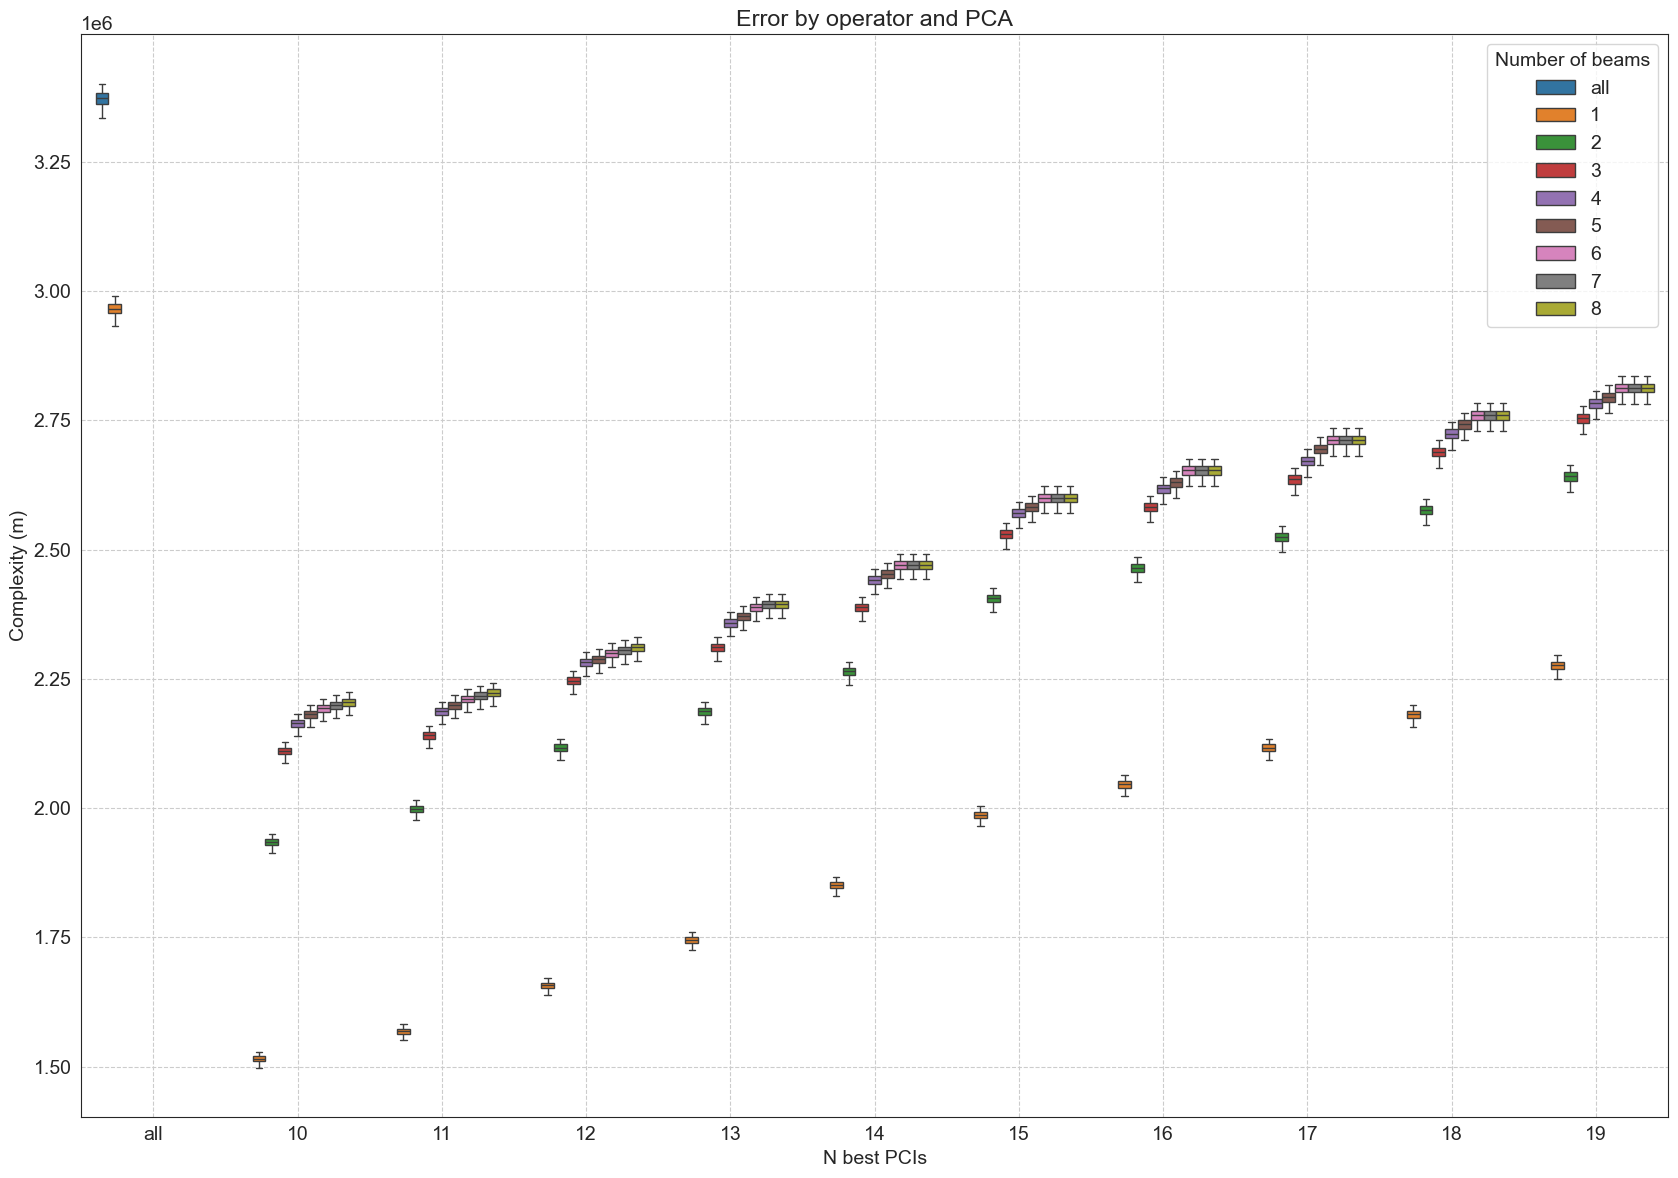

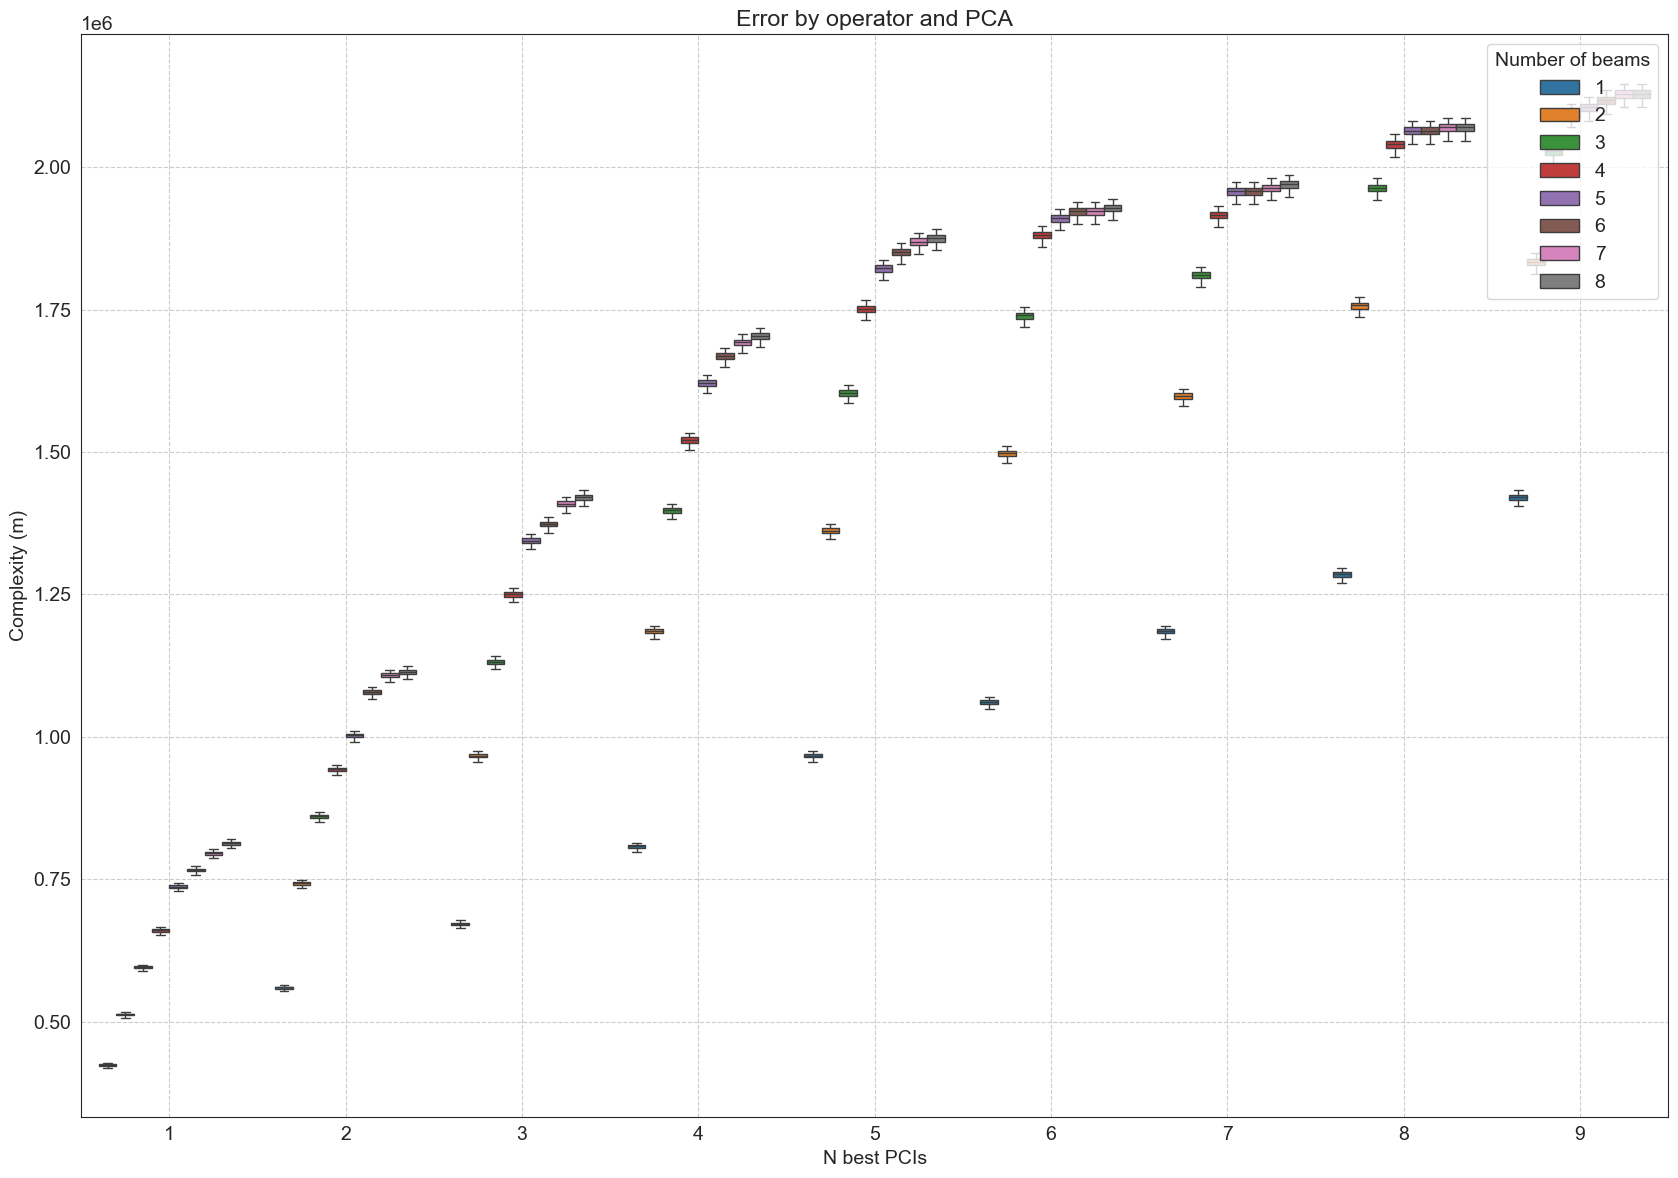

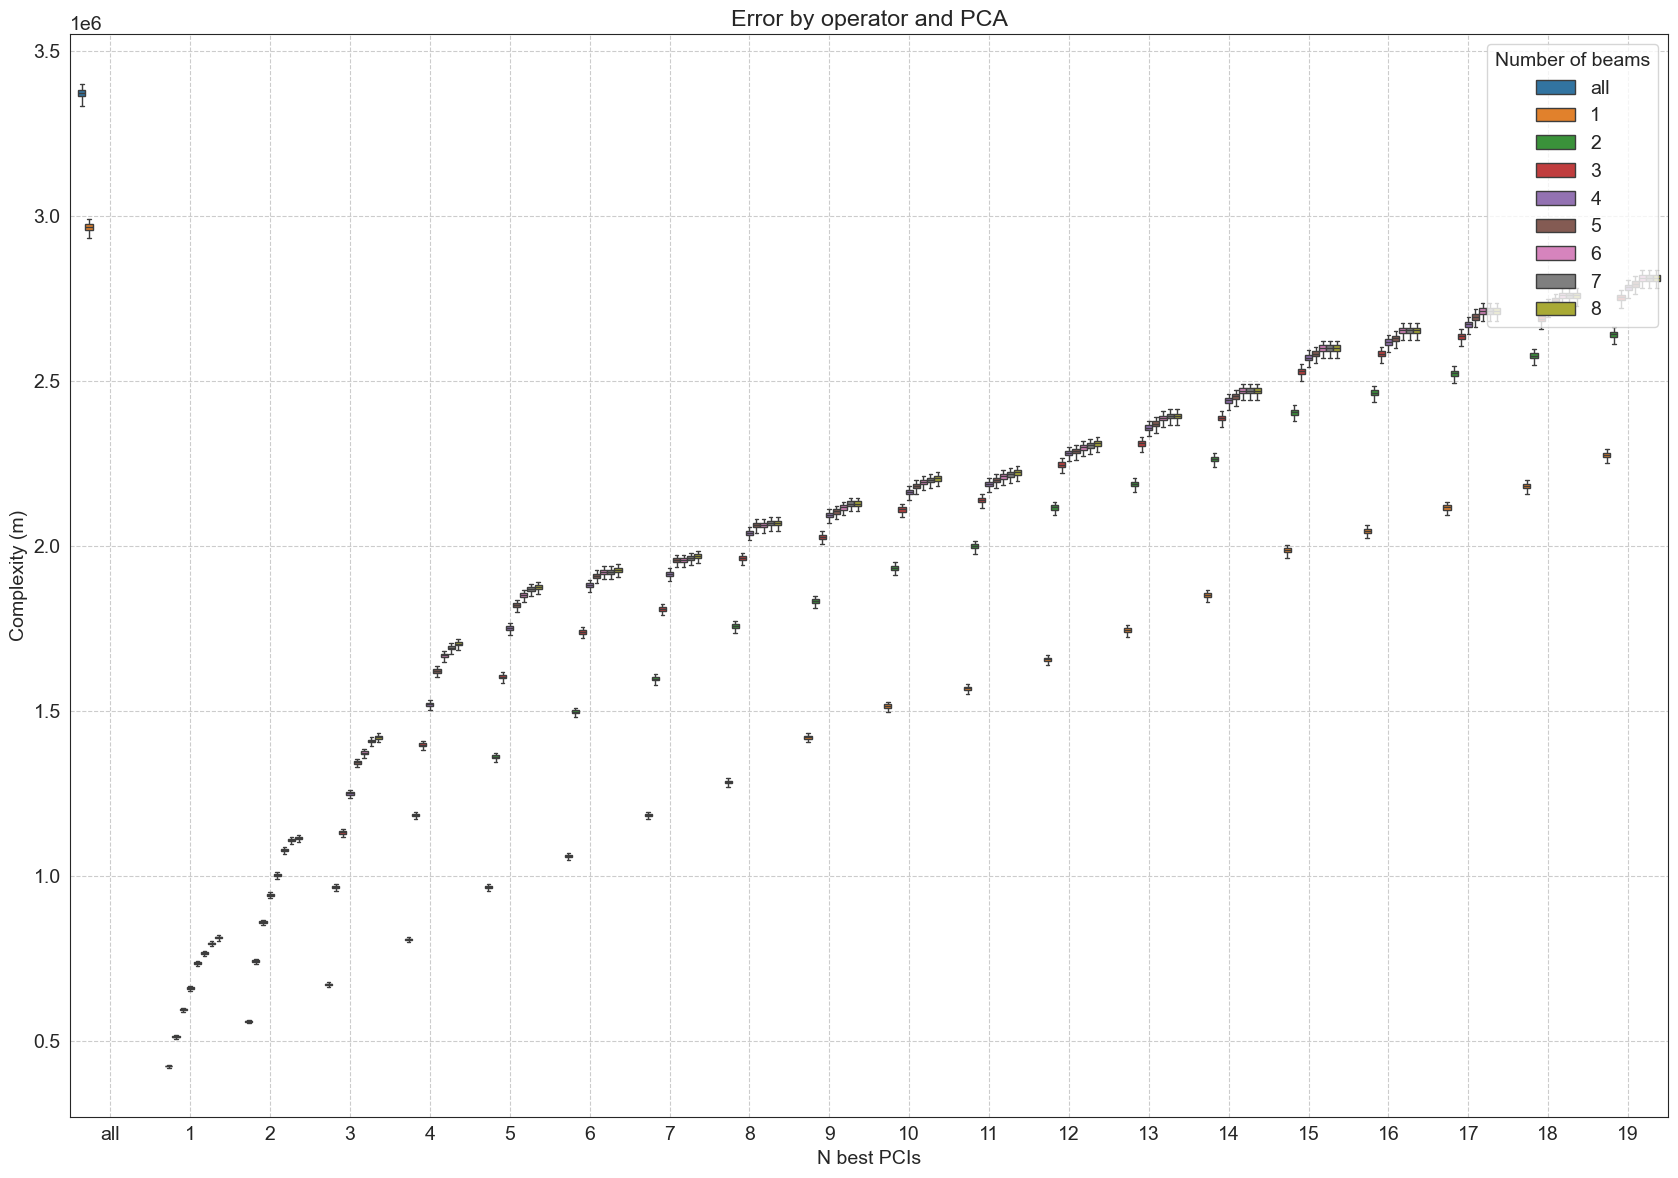

In [68]:

def plot_complexity(df: pd.DataFrame):
    plt.rcParams.update({"font.size": 14})

    plt.figure(figsize=(17, 12))
    sns.set_style("white")
    sns.boxplot(
        data=df,
        x='n_best_pcis',
        y='complexity',
        hue='n_best_beams',
        showfliers=False,
    )

    # Add labels and title
    plt.xlabel('N best PCIs')
    plt.ylabel('Complexity (m)')
    plt.title('Error by operator and PCA')

    plt.legend(title='Number of beams', loc='upper right')
    plt.grid(linestyle='--')
    plt.tight_layout()
    plt.show()


#plot(df[df['n_best_pcis'] == 9])

highs = [str(i) for i in range(10, 20)] + ['all']
lows = [str(i) for i in range(1, 10)]


def plottt(df):
    plot_complexity(df[df['n_best_pcis'].isin(highs)])
    plot_complexity(df[df['n_best_pcis'].isin(lows)])
    plot_complexity(df)


plottt(data_df)

In [77]:
data_df.groupby(['operator', 'config', 'run'])['runtime'].count()

operator  config                            run
1         All PCIs and all beams            0.0    2517
                                            1.0    2585
                                            2.0    2537
                                            3.0    2469
                                            4.0    2537
                                                   ... 
88        Only best PCI and only best beam  5.0    2518
                                            6.0    2518
                                            7.0    2502
                                            8.0    2650
                                            9.0    2499
Name: runtime, Length: 160, dtype: int64